# Breast Cancer Classification with a Neural Network

**Data:** Wisconsin Breast Cancer diagnostic dataset (`data.csv`) — the same underlying data as `sklearn.datasets.load_breast_cancer()`, loaded here directly from the CSV file.

**Model:** Multilayer Perceptron (`MLPClassifier`) — a feedforward neural network, trained with scikit-learn.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
%matplotlib inline

## 2. Load the data

In [2]:
df = pd.read_csv("data.csv")

# Drop columns that aren't features (id, and any stray unnamed/empty column
# from a trailing comma in the CSV)
df = df.drop(columns=[c for c in df.columns if "Unnamed" in c or c == "id"], errors="ignore")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Class balance:")
df["diagnosis"].value_counts()

Class balance:


diagnosis
B    357
M    212
Name: count, dtype: int64

## 3. Encode target and split features/labels

In [4]:
# diagnosis: M = Malignant, B = Benign  ->  1 / 0
le = LabelEncoder()
y = le.fit_transform(df["diagnosis"])
X = df.drop(columns=["diagnosis"]).values
feature_names = df.drop(columns=["diagnosis"]).columns.tolist()

print("Classes:", list(le.classes_))
print("X shape:", X.shape, "| y shape:", y.shape)

Classes: ['B', 'M']
X shape: (569, 30) | y shape: (569,)


## 4. Train / test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Train size: 455  |  Test size: 114


## 5. Feature scaling

Neural networks train much better (and often only converge) when inputs are standardized.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Build and train the neural network

A feedforward network with two hidden layers (32 → 16 neurons), ReLU activations, Adam optimizer, and early stopping.

In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=1e-4,                    # L2 regularization
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    validation_fraction=0.1,
    random_state=RANDOM_STATE,
)

model.fit(X_train_scaled, y_train)
print(f"Stopped after {model.n_iter_} iterations")

Stopped after 45 iterations


## 7. Evaluate on the test set

In [8]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test ROC AUC:  {auc:.4f}")

Test Accuracy: 0.9474
Test ROC AUC:  0.9934


In [9]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           B       0.93      0.99      0.96        72
           M       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[71  1]
 [ 5 37]]


## 8. Visualize results

Training loss curve, confusion matrix, and ROC curve.

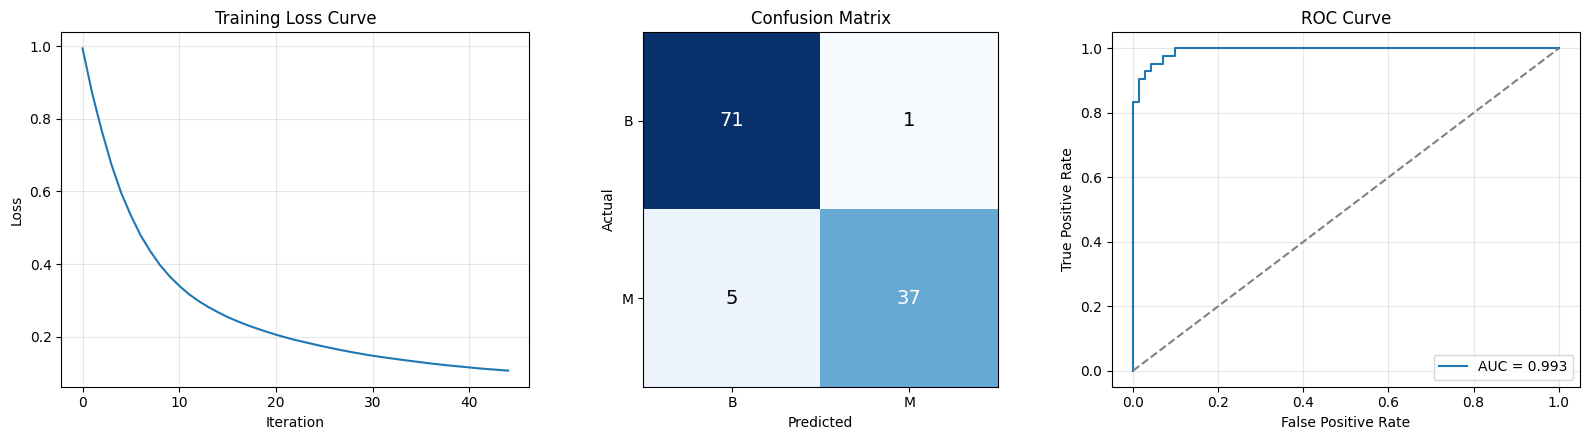

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curve
axes[0].plot(model.loss_curve_)
axes[0].set_title("Training Loss Curve")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# Confusion matrix
axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(le.classes_); axes[1].set_yticklabels(le.classes_)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                      color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150)
plt.show()

## Notes

- Model: scikit-learn `MLPClassifier` (a true feedforward neural network). TensorFlow/Keras isn't installed in this environment by default — swap in a `keras.Sequential` model with the same architecture if you'd like finer control (dropout, batch norm, custom callbacks, etc.).
- Feature scaling is essential here — the raw feature scales vary by orders of magnitude (e.g. `area_mean` vs `smoothness_mean`), which would otherwise dominate the loss landscape.
- Next steps to try: k-fold cross-validation, a grid/random search over `hidden_layer_sizes`/`alpha`, or plotting a learning curve to check for overfitting.